In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer

from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.varmax import VARMAX

# from keras.models import Sequential
# from keras.layers import LSTM, Dense

from prophet import Prophet

from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import mean_squared_error, mean_absolute_error

import constantes as const
from loader import cargar_dataset

In [2]:
columnas_descartables = [
    const.COL_INDICATIVO,
    const.COL_NOMBRE
]

In [3]:
df = cargar_dataset(const.PATH_DF_PROCESADO).drop(columns = columnas_descartables)

In [4]:
display(df.sample(20))

,fecha,provincia,altitud,tmed,prec,tmin,tmax,velmedia,sol,hrMedia,racha,hrMax,hrMin,lon,lat
5329324,2018-05-20,GIPUZKOA,150,14.8,0.0,11.8,17.7,1.1,<NA>,79.0,5.8,94.0,69.0,-2.397222,43.317222
2811211,2009-08-30,CADIZ,105,31.2,0.0,25.6,36.7,3.6,<NA>,42.0,10.8,55.0,31.0,-5.783333,36.663889
5075360,2017-07-25,PONTEVEDRA,113,21.1,0.0,15.4,26.8,3.3,13.6,59.0,9.4,82.0,46.0,-8.615833,42.438333
3077182,2010-09-14,SANTA CRUZ DE TENERIFE,190,25.4,0.6,20.8,29.9,2.5,<NA>,71.0,16.9,94.0,44.0,-17.306389,28.054167
3255319,2011-05-18,SALAMANCA,748,16.2,5.8,11.0,21.4,2.2,<NA>,72.0,7.8,96.0,51.0,-6.608889,40.851389
6520294,2022-03-08,SORIA,1100,5.4,0.4,1.2,9.6,4.2,<NA>,78.0,11.7,97.0,51.0,-2.5075,41.600556
6959223,2023-07-25,VALENCIA,305,28.7,0.0,20.9,36.5,2.8,<NA>,42.0,10.3,76.0,15.0,-0.79,39.133611
1627543,1999-12-03,VALENCIA,11,14.3,0.0,8.6,20.0,2.5,8.1,81.0,8.9,<NA>,<NA>,-0.366389,39.480556
1049064,1991-12-07,BURGOS,891,2.1,0.0,-0.6,4.8,3.6,0.0,92.0,10.3,<NA>,<NA>,-3.620278,42.356944
404155,1979-05-04,ILLES BALEARS,91,11.2,0.0,7.2,15.2,4.7,10.8,62.0,8.9,<NA>,<NA>,4.215556,39.854722


In [5]:
corr = df.drop(columns = [const.COL_PROVINCIA]).corr()

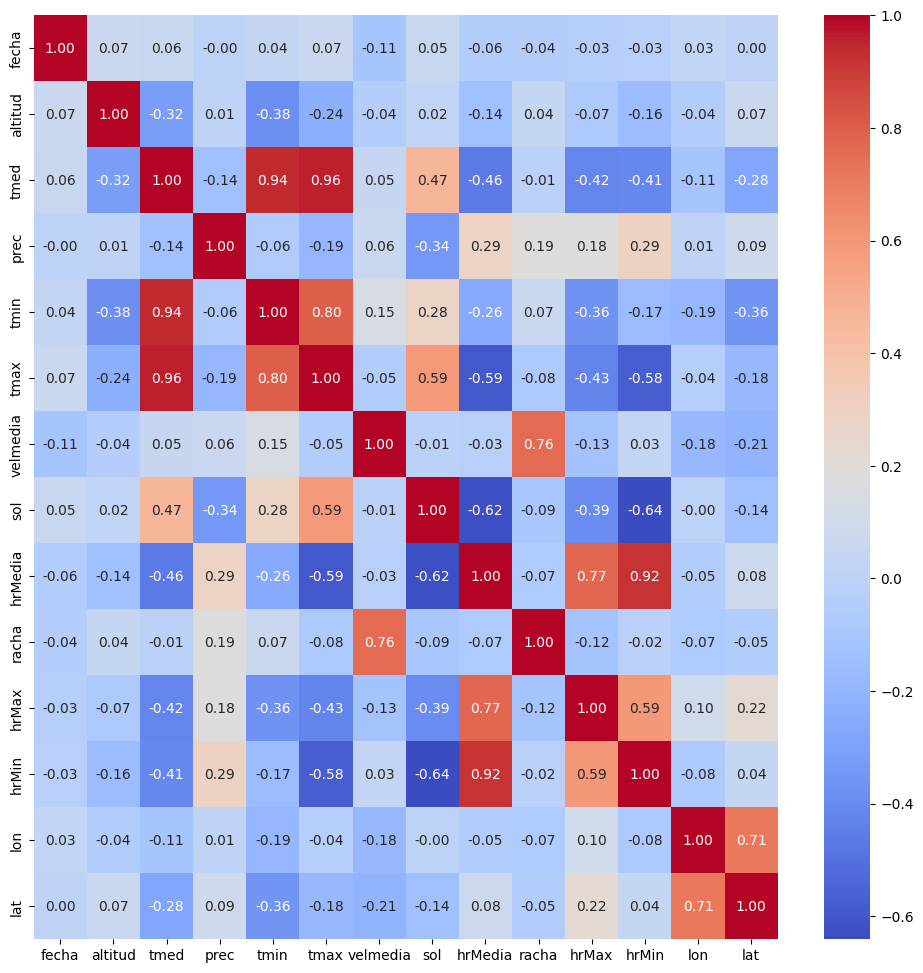

In [6]:
plt.figure(figsize=(12, 12))
sns.heatmap(corr,
            cmap="coolwarm",
            annot=True,
            xticklabels=corr.columns,
            yticklabels=corr.columns,
            fmt=".2f")
plt.show()

In [7]:
### Parte experimental###

In [8]:
variables_dependientes = [
                            const.COL_TMAX,
                            const.COL_TMED,
                            const.COL_TMIN,
                            const.COL_PREC,
                            const.COL_RACHA
                        ]

In [9]:
df_agg = (
    df.set_index(const.COL_FECHA)
      .groupby([pd.Grouper(freq = 'MS'), const.COL_PROVINCIA])
      .agg({
          const.COL_TMAX:'max',
          const.COL_TMED:'mean',
          const.COL_TMIN:'min',
          const.COL_PREC:'sum',
          const.COL_RACHA:'max'
          # const.COL_VELMEDIA: 'mean',
          # const.COL_SOL: 'mean',
          # const.COL_HRMAX: 'max',
          # const.COL_HRMEDIA: 'mean'
          # const.COL_HRMIN: 'min'
      })
    .reset_index()
)

In [10]:
df_agg = (
            df_agg
                .set_index(const.COL_FECHA)
                .groupby(const.COL_PROVINCIA)
                .apply(lambda g: g.asfreq('MS').interpolate(method = 'linear', limit_direction = 'both'))
                .reset_index(level = 0)
)

In [11]:
cols_transformer = [const.COL_PREC, const.COL_RACHA]

transformer = PowerTransformer(method = 'yeo-johnson')
df_agg[cols_transformer] = transformer.fit_transform(df_agg[cols_transformer])

In [12]:
cols_scaler = df_agg.select_dtypes(include = 'number').columns

scaler = StandardScaler()
df_agg[cols_scaler] = scaler.fit_transform(df_agg[cols_scaler])

In [13]:
df_agg.sample(20)

,provincia,tmax,tmed,tmin,prec,racha
fecha,,,,,,
2012-02-01,GIRONA,-0.563394,-1.548915,-2.096153,-0.754157,1.863151
1983-07-01,GIPUZKOA,0.581999,1.029905,1.743882,0.429645,0.415864
2005-03-01,VALENCIA,-0.051336,-0.429094,-1.412510,-0.596263,-0.335727
1998-09-01,HUELVA,0.972780,1.226786,1.220241,-0.412082,-0.823693
2000-05-01,JAEN,0.743702,0.704987,0.754782,-0.113358,-0.727718
2013-01-01,SEGOVIA,-1.574035,-1.735302,-1.325237,1.088503,1.781839
1979-06-01,VALLADOLID,0.501148,0.574935,0.405688,-0.728263,-0.506703
2021-02-01,CORDOBA,-0.617295,-0.467921,-0.379774,1.162293,0.371829
2024-06-01,CEUTA,0.272069,1.213614,2.354797,-1.660811,-1.083638


In [14]:
provincia = "VALENCIA"
df_prov = df_agg[df_agg['provincia'] == provincia]#.set_index('fecha')
# df_prov = df_prov[variables_dependientes]
df_prov = df_prov[variables_dependientes]
# df_prov = df_prov.astype('float64')

# Split train / test
cutoff = '2022-12-31'
train = df_prov.loc[:cutoff]
test = df_prov.loc[cutoff:]



In [15]:
raise Exception()

Exception: 

In [ ]:
model = VAR(df_prov)
p = model.select_order(maxlags=12)
optimal_p = p.selected_orders['aic']
optimal_p

In [17]:
# model = VAR(df_prov)
# model_fitted = model.fit(12)

# forecast = model_fitted.forecast(y = model_fitted.y, steps = 60)

model_train = VAR(train)
model_fitted_train = model_train.fit(12)

lag_order = model_fitted_train.k_ar
forecast_input = train.values[-lag_order:]

# Predecir
forecast_test = model_fitted_train.forecast(y=forecast_input, steps=len(test))

# Calcular error RMSE
rmse_vals = {}
for i, col in enumerate(test.columns):
    rmse_vals[col] = rmse(test[col].values, forecast_test[:, i])

print("RMSE por variable:", rmse_vals)

RMSE por variable: {'tmax': np.float64(0.36294537678923183), 'tmed': np.float64(0.23608651259193625), 'tmin': np.float64(0.3254525665844876), 'prec': np.float64(0.9292570912093577), 'racha': np.float64(0.6065834288865094)}


C:\Users\Big Data\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


RMSE en escala transformada: {'tmax': np.float64(0.36294537678923183), 'tmed': np.float64(0.23608651259193625), 'tmin': np.float64(0.3254525665844876), 'prec': np.float64(0.9292570912093577), 'racha': np.float64(0.6065834288865094)}
RMSE en escala original: {'tmax': np.float64(2.6934299765887184), 'tmed': np.float64(1.4801642741192398), 'tmin': np.float64(2.2374660253114875), 'prec': np.float64(824.8157481179469), 'racha': np.float64(4.168882517771622)}


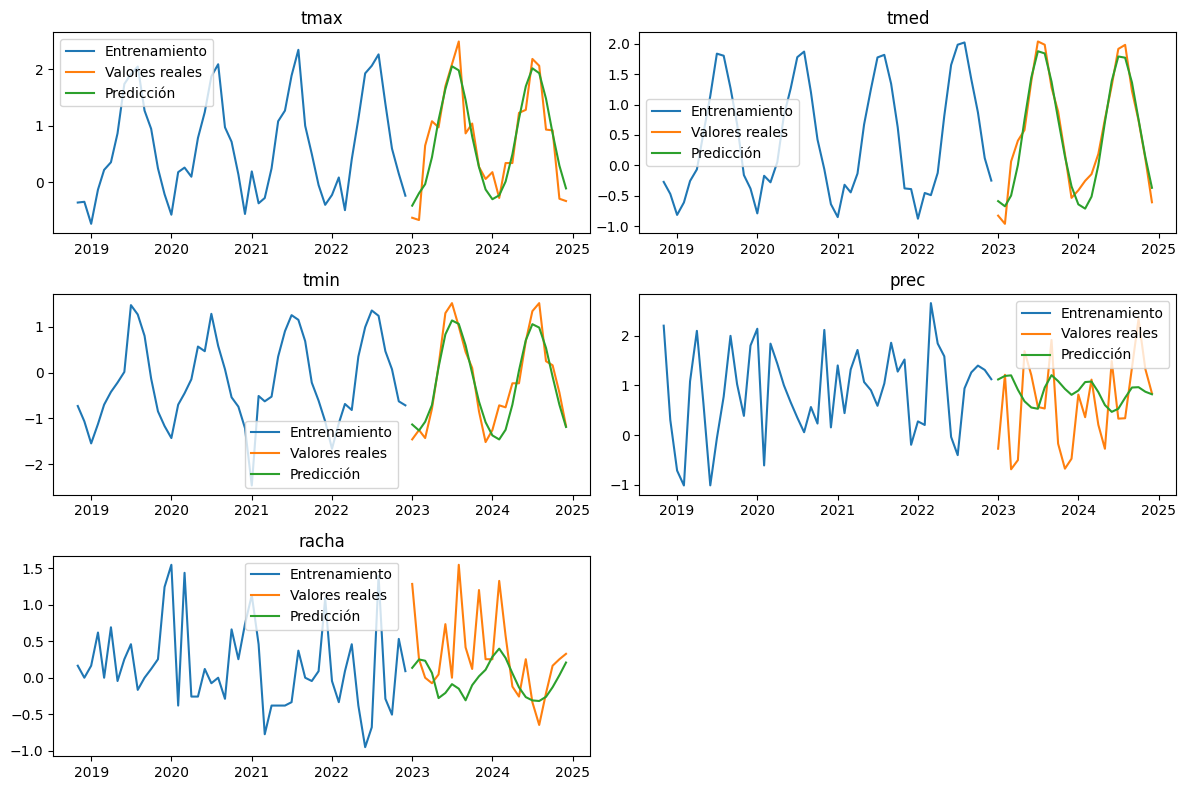

In [18]:
forecast_test_df = pd.DataFrame(forecast_test, 
                                index=test.index, 
                                columns=test.columns)


rmse_vals = {}
for col in test.columns:
    rmse_vals[col] = rmse(test[col].values, forecast_test_df[col].values)

print("RMSE en escala transformada:", rmse_vals)

test_original_scale = pd.DataFrame(scaler.inverse_transform(test), 
                                   index=test.index, 
                                   columns=test.columns)

forecast_original_scale = pd.DataFrame(scaler.inverse_transform(forecast_test_df), 
                                       index=test.index, 
                                       columns=test.columns)

# Invertir Yeo-Johnson para prec y racha
if 'prec' in test.columns and 'racha' in test.columns:
    forecast_original_scale[['prec', 'racha']] = transformer.inverse_transform(
        forecast_original_scale[['prec', 'racha']])
    test_original_scale[['prec', 'racha']] = transformer.inverse_transform(
        test_original_scale[['prec', 'racha']])

# 6. Calcular RMSE en escala original
rmse_vals_original = {}
for col in test_original_scale.columns:
    rmse_vals_original[col] = rmse(test_original_scale[col].values, 
                                  forecast_original_scale[col].values)

print("RMSE en escala original:", rmse_vals_original)

# 6. Visualizar resultados
plt.figure(figsize=(12, 8))
for i, col in enumerate(variables_dependientes):
    plt.subplot(3, 2, i+1)
    # Mostrar los últimos 50 puntos del entrenamiento
    plt.plot(train.index[-50:], train[col].values[-50:], label='Entrenamiento')
    plt.plot(test.index, test[col].values, label='Valores reales')
    plt.plot(test.index, forecast_test_df[col].values, label='Predicción')
    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model_fitted.k_ar

In [ ]:
# Ajuste del modelo VARMAX
model = VARMAX(train, order=(1,1), trend='c')  # p=2, q=1
res = model.fit(disp=False)

print(res.summary())

# Predicción sobre el conjunto de test
pred = res.get_prediction(start=test.index[0], end=test.index[-1])
pred_mean = pred.predicted_mean

# Forecast a futuro
forecast_steps = 12 * 5  # 5 años
fc = res.get_forecast(steps=forecast_steps)
fc_mean = fc.predicted_mean

print(fc_mean.head())

In [ ]:
for col in test.columns:
    mse = mean_squared_error(test[col], pred_mean[col])
    rmse = np.sqrt(mse)
    print(f"{col}: RMSE = {rmse:.2f}")